# 스마트 창고 출고 지연 예측 — Model v1

베이스라인 대비 개선 사항:
- 데이터 경로 수정 (`./open/`)
- `layout_info.csv` merge
- KFold → Group K-Fold (`scenario_id` 기준)
- 평가 지표 MAE → RMSE
- Lag 피처 (t-1, t-2, t-3)
- Rolling 피처 (3, 5 스텝 이동평균 / 표준편차)
- LightGBM + XGBoost + CatBoost 앙상블

## 0. 라이브러리 로드

In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import xgboost as xgb
import catboost as cb
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

SEED   = 42
N_FOLD = 5
TARGET = 'avg_delay_minutes_next_30m'
ID_COLS = ['ID', 'layout_id', 'scenario_id']

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

## 1. 데이터 로드

In [2]:
train  = pd.read_csv('./open/train.csv')
test   = pd.read_csv('./open/test.csv')
layout = pd.read_csv('./open/layout_info.csv')

print(f'train  : {train.shape}')
print(f'test   : {test.shape}')
print(f'layout : {layout.shape}')

train  : (250000, 94)
test   : (50000, 93)
layout : (300, 15)


## 2. layout_info merge

In [3]:
train = train.merge(layout, on='layout_id', how='left')
test  = test.merge(layout, on='layout_id', how='left')

print(f'merge 후 train : {train.shape}')
print(f'merge 후 test  : {test.shape}')

# layout_type 레이블 인코딩
le = LabelEncoder()
train['layout_type'] = le.fit_transform(train['layout_type'].astype(str))
test['layout_type']  = le.transform(test['layout_type'].astype(str))
print(f'layout_type 클래스: {list(le.classes_)}')

merge 후 train : (250000, 108)
merge 후 test  : (50000, 107)
layout_type 클래스: ['grid', 'hub_spoke', 'hybrid', 'narrow']


## 3. 시계열 피처 엔지니어링

In [4]:
# scenario_id 기준 정렬 (타임스텝 순서 보장)
train = train.sort_values(['scenario_id', 'shift_hour']).reset_index(drop=True)
test  = test.sort_values(['scenario_id', 'shift_hour']).reset_index(drop=True)

# 시계열 피처를 생성할 기준 컬럼
ts_features = [
    'order_inflow_15m', 'robot_utilization', 'congestion_score',
    'fault_count_15m',  'loading_dock_util', 'battery_mean',
    'blocked_path_15m', 'task_reassign_15m', 'low_battery_ratio',
    'avg_trip_distance'
]

def make_ts_features(df, cols, group_col='scenario_id'):
    """Lag(1,2,3) + Rolling mean/std(3,5) 피처 생성
    주의: 동일 시나리오 내에서만 계산, 시나리오 경계 누수 없음
    """
    df = df.copy()
    grp = df.groupby(group_col)

    for col in cols:
        # Lag 피처
        for lag in [1, 2, 3]:
            df[f'{col}_lag{lag}'] = grp[col].shift(lag)

        # Rolling 평균
        for win in [3, 5]:
            df[f'{col}_roll_mean{win}'] = (
                grp[col]
                .transform(lambda x: x.shift(1).rolling(win, min_periods=1).mean())
            )
            # Rolling 표준편차
            df[f'{col}_roll_std{win}'] = (
                grp[col]
                .transform(lambda x: x.shift(1).rolling(win, min_periods=2).std())
            )

        # 누적 합계 (시나리오 내)
        df[f'{col}_cumsum'] = grp[col].transform(lambda x: x.shift(1).cumsum())

    return df

print('시계열 피처 생성 중...')
train = make_ts_features(train, ts_features)
test  = make_ts_features(test,  ts_features)

new_feat_count = len(ts_features) * (3 + 2*2 + 1)  # lag3 + roll_mean2 + roll_std2 + cumsum1
print(f'생성된 시계열 피처 수: {new_feat_count}')
print(f'train shape: {train.shape}')

시계열 피처 생성 중...
생성된 시계열 피처 수: 80
train shape: (250000, 188)


## 4. 추가 피처 엔지니어링

In [5]:
def make_extra_features(df):
    df = df.copy()

    # 타임스텝 순번 (시나리오 내)
    df['time_step'] = df.groupby('scenario_id').cumcount()

    # 로봇 가용률 (active / total)
    df['robot_active_ratio'] = df['robot_active'] / (df['robot_active'] + df['robot_idle'] + df['robot_charging'] + 1e-6)

    # 배터리 부족 × 혼잡도 (복합 스트레스 지표)
    df['battery_congestion'] = df['low_battery_ratio'] * df['congestion_score']

    # 긴급 주문 × 주문 유입량
    df['urgent_volume'] = df['urgent_order_ratio'] * df['order_inflow_15m']

    # 장비 결함 × 평균 복구 시간
    df['fault_impact'] = df['fault_count_15m'] * df['avg_recovery_time']

    # 로딩 독 포화도 (대기 × 활용률)
    df['dock_stress'] = df['outbound_truck_wait_min'] * df['loading_dock_util']

    return df

train = make_extra_features(train)
test  = make_extra_features(test)
print(f'추가 피처 후 train shape: {train.shape}')

추가 피처 후 train shape: (250000, 194)


## 5. 피처 / 타겟 설정

In [6]:
drop_cols = ID_COLS + [TARGET]
feat_cols = [c for c in train.columns if c not in drop_cols]

X     = train[feat_cols]
y     = train[TARGET]
X_test = test[feat_cols]
groups = train['scenario_id']

print(f'최종 피처 수: {len(feat_cols)}')
print(f'X shape    : {X.shape}')
print(f'X_test shape: {X_test.shape}')

최종 피처 수: 190
X shape    : (250000, 190)
X_test shape: (50000, 190)


## 6. Group K-Fold 교차 검증 함수

In [7]:
gkf = GroupKFold(n_splits=N_FOLD)

def run_cv(model_fn, model_name, X, y, X_test, groups, fit_kwargs=None):
    """Group K-Fold OOF 예측 + 테스트 예측 반환"""
    oof   = np.zeros(len(X))
    preds = np.zeros(len(X_test))
    fold_scores = []

    for fold, (tr_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        X_tr, y_tr   = X.iloc[tr_idx], y.iloc[tr_idx]
        X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]

        model = model_fn()
        if fit_kwargs:
            model.fit(X_tr, y_tr, **fit_kwargs(X_val, y_val))
        else:
            model.fit(X_tr, y_tr)

        oof[val_idx] = model.predict(X_val)
        preds += model.predict(X_test) / N_FOLD

        score = rmse(y_val, oof[val_idx])
        fold_scores.append(score)
        print(f'  [{model_name}] Fold {fold+1}  RMSE: {score:.4f}')

    total = rmse(y, oof)
    print(f'  [{model_name}] OOF RMSE: {total:.4f}  (folds: {[round(s,4) for s in fold_scores]})\n')
    return oof, preds, total

## 7. LightGBM

In [8]:
lgb_params = dict(
    n_estimators   = 2000,
    learning_rate  = 0.03,
    max_depth      = 7,
    num_leaves     = 63,
    subsample      = 0.8,
    colsample_bytree = 0.8,
    reg_alpha      = 0.1,
    reg_lambda     = 0.1,
    min_child_samples = 20,
    random_state   = SEED,
    verbose        = -1,
    n_jobs         = -1,
)

def lgb_fn():
    return LGBMRegressor(**lgb_params)

def lgb_fit_kwargs(X_val, y_val):
    return dict(
        eval_set=[(X_val, y_val)],
        callbacks=[
            lgb.early_stopping(100, verbose=False),
            lgb.log_evaluation(200)
        ]
    )

print('=== LightGBM ===')
lgb_oof, lgb_pred, lgb_score = run_cv(lgb_fn, 'LGB', X, y, X_test, groups, lgb_fit_kwargs)

=== LightGBM ===
[200]	valid_0's l2: 483.101
  [LGB] Fold 1  RMSE: 21.9721
[200]	valid_0's l2: 462.17
[400]	valid_0's l2: 461.556
  [LGB] Fold 2  RMSE: 21.4726
[200]	valid_0's l2: 399.322
  [LGB] Fold 3  RMSE: 19.9696
[200]	valid_0's l2: 506.482
  [LGB] Fold 4  RMSE: 22.4968
[200]	valid_0's l2: 452.366
  [LGB] Fold 5  RMSE: 21.2545
  [LGB] OOF RMSE: 21.4499  (folds: [np.float64(21.9721), np.float64(21.4726), np.float64(19.9696), np.float64(22.4968), np.float64(21.2545)])



## 8. XGBoost

In [9]:
xgb_params = dict(
    n_estimators          = 2000,
    learning_rate         = 0.03,
    max_depth             = 7,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    reg_alpha             = 0.1,
    reg_lambda            = 0.1,
    min_child_weight      = 5,
    random_state          = SEED,
    verbosity             = 0,
    n_jobs                = -1,
    tree_method           = 'hist',
    early_stopping_rounds = 100,
)

def xgb_fn():
    return XGBRegressor(**xgb_params)

def xgb_fit_kwargs(X_val, y_val):
    return dict(
        eval_set=[(X_val, y_val)],
        verbose=False
    )

print('=== XGBoost ===')
xgb_oof, xgb_pred, xgb_score = run_cv(xgb_fn, 'XGB', X, y, X_test, groups, xgb_fit_kwargs)

=== XGBoost ===
  [XGB] Fold 1  RMSE: 21.9571
  [XGB] Fold 2  RMSE: 21.4634
  [XGB] Fold 3  RMSE: 19.8966
  [XGB] Fold 4  RMSE: 22.5481
  [XGB] Fold 5  RMSE: 21.1955
  [XGB] OOF RMSE: 21.4305  (folds: [np.float64(21.9571), np.float64(21.4634), np.float64(19.8966), np.float64(22.5481), np.float64(21.1955)])



## 9. CatBoost

In [10]:
cat_params = dict(
    iterations        = 2000,
    learning_rate     = 0.03,
    depth             = 7,
    l2_leaf_reg       = 3,
    random_seed       = SEED,
    verbose           = 0,
    early_stopping_rounds = 100,
    task_type         = 'CPU',
)

def cat_fn():
    return CatBoostRegressor(**cat_params)

def cat_fit_kwargs(X_val, y_val):
    return dict(eval_set=(X_val, y_val))

print('=== CatBoost ===')
cat_oof, cat_pred, cat_score = run_cv(cat_fn, 'CAT', X, y, X_test, groups, cat_fit_kwargs)

=== CatBoost ===
  [CAT] Fold 1  RMSE: 22.0354
  [CAT] Fold 2  RMSE: 21.5400
  [CAT] Fold 3  RMSE: 19.8706
  [CAT] Fold 4  RMSE: 22.4769
  [CAT] Fold 5  RMSE: 21.1813
  [CAT] OOF RMSE: 21.4393  (folds: [np.float64(22.0354), np.float64(21.54), np.float64(19.8706), np.float64(22.4769), np.float64(21.1813)])



## 10. 앙상블 (가중 평균)

In [11]:
# 각 모델 RMSE의 역수를 가중치로 사용 (성능 좋을수록 높은 가중치)
scores = np.array([lgb_score, xgb_score, cat_score])
weights = (1 / scores) / (1 / scores).sum()

print(f'LGB  RMSE: {lgb_score:.4f}  가중치: {weights[0]:.4f}')
print(f'XGB  RMSE: {xgb_score:.4f}  가중치: {weights[1]:.4f}')
print(f'CAT  RMSE: {cat_score:.4f}  가중치: {weights[2]:.4f}')

# OOF 앙상블
ens_oof  = weights[0]*lgb_oof  + weights[1]*xgb_oof  + weights[2]*cat_oof
ens_pred = weights[0]*lgb_pred + weights[1]*xgb_pred + weights[2]*cat_pred

ens_score = rmse(y, ens_oof)
print(f'\n앙상블 OOF RMSE: {ens_score:.4f}')

# 단순 평균도 비교
simple_oof  = (lgb_oof  + xgb_oof  + cat_oof)  / 3
simple_pred = (lgb_pred + xgb_pred + cat_pred) / 3
print(f'단순 평균 OOF RMSE: {rmse(y, simple_oof):.4f}')

LGB  RMSE: 21.4499  가중치: 0.3332
XGB  RMSE: 21.4305  가중치: 0.3335
CAT  RMSE: 21.4393  가중치: 0.3333

앙상블 OOF RMSE: 21.3531
단순 평균 OOF RMSE: 21.3531


## 11. 모델 성능 요약

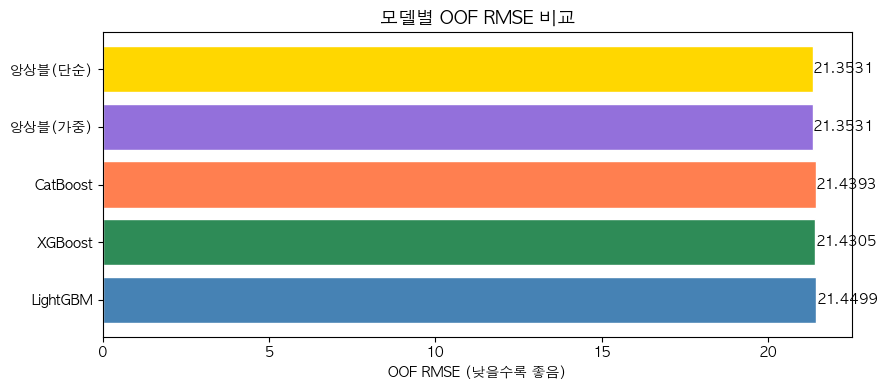

In [12]:
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

model_names  = ['LightGBM', 'XGBoost', 'CatBoost', '앙상블(가중)', '앙상블(단순)']
model_scores = [
    lgb_score, xgb_score, cat_score,
    ens_score, rmse(y, simple_oof)
]

colors = ['steelblue', 'seagreen', 'coral', 'mediumpurple', 'gold']

plt.figure(figsize=(9, 4))
bars = plt.barh(model_names, model_scores, color=colors, edgecolor='white')
for bar, score in zip(bars, model_scores):
    plt.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{score:.4f}', va='center', fontsize=10)
plt.xlabel('OOF RMSE (낮을수록 좋음)')
plt.title('모델별 OOF RMSE 비교', fontsize=13)
plt.tight_layout()
plt.show()

## 12. 피처 중요도 (LightGBM 기준)

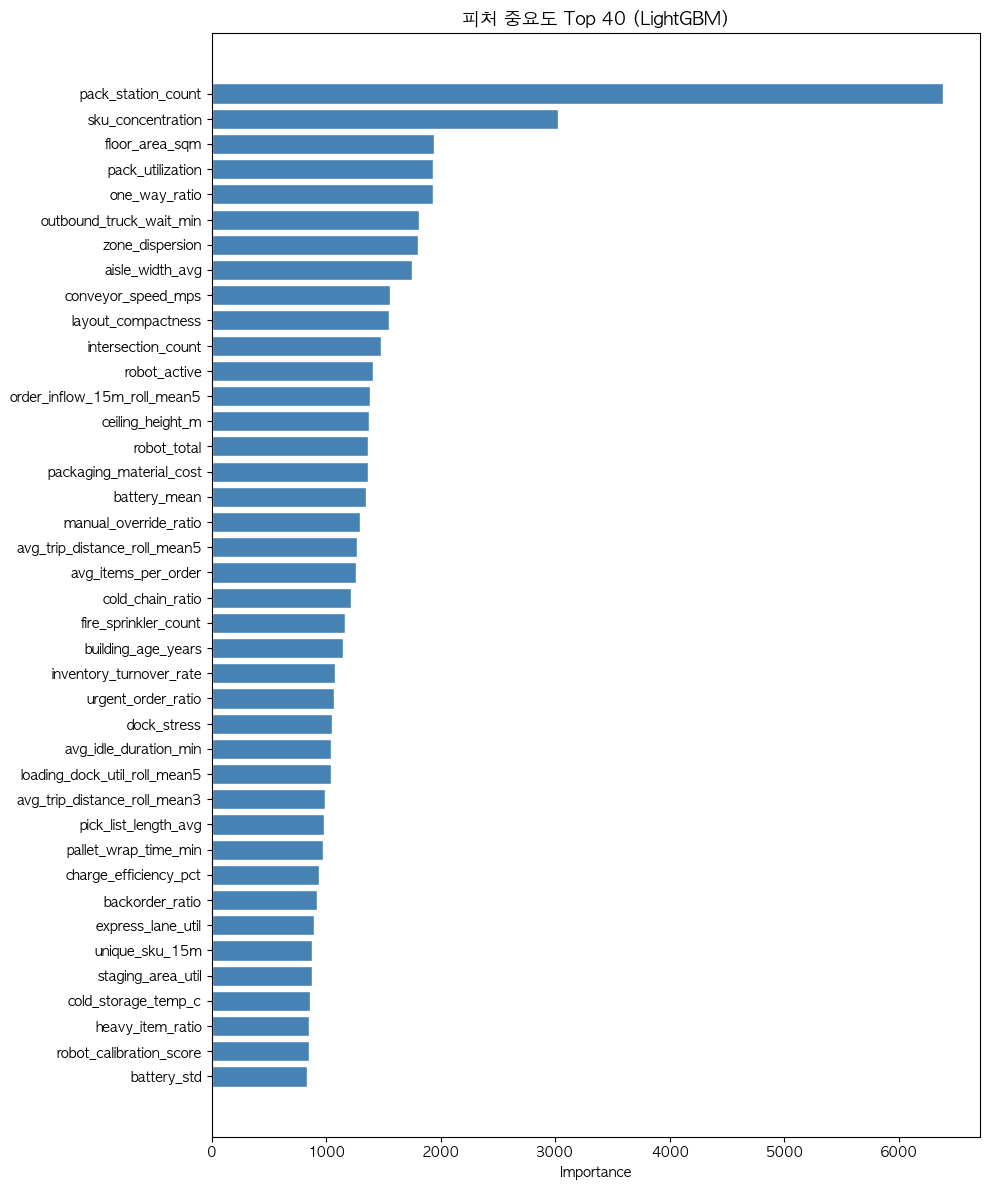

Top 20 피처:
                     feature  importance
          pack_station_count        6387
           sku_concentration        3022
              floor_area_sqm        1944
            pack_utilization        1933
               one_way_ratio        1932
     outbound_truck_wait_min        1807
             zone_dispersion        1800
             aisle_width_avg        1752
          conveyor_speed_mps        1553
          layout_compactness        1550
          intersection_count        1479
                robot_active        1412
 order_inflow_15m_roll_mean5        1386
            ceiling_height_m        1373
                 robot_total        1369
     packaging_material_cost        1361
                battery_mean        1345
       manual_override_ratio        1292
avg_trip_distance_roll_mean5        1268
         avg_items_per_order        1260


In [13]:
# 마지막 fold LGB 모델 재학습으로 피처 중요도 확인
fi_model = LGBMRegressor(**lgb_params)
fi_model.fit(X, y)

fi = pd.DataFrame({
    'feature': feat_cols,
    'importance': fi_model.feature_importances_
}).sort_values('importance', ascending=False)

top40 = fi.head(40)

plt.figure(figsize=(10, 12))
plt.barh(top40['feature'][::-1], top40['importance'][::-1],
         color='steelblue', edgecolor='white')
plt.title('피처 중요도 Top 40 (LightGBM)', fontsize=13)
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

print('Top 20 피처:')
print(fi.head(20).to_string(index=False))

## 13. 제출 파일 생성

In [14]:
# 가중 앙상블 vs 단순 평균 중 성능 좋은 것 선택
best_pred = ens_pred if ens_score <= rmse(y, simple_oof) else simple_pred
best_label = '가중앙상블' if ens_score <= rmse(y, simple_oof) else '단순평균'
print(f'선택된 앙상블: {best_label}')

submission = pd.read_csv('./open/sample_submission.csv')
submission[TARGET] = best_pred
submission.to_csv('./submission_v1.csv', index=False)

print(f'submission_v1.csv 저장 완료')
print(submission.head())
print(f'\n예측값 통계:')
print(submission[TARGET].describe())

선택된 앙상블: 가중앙상블
submission_v1.csv 저장 완료
            ID  avg_delay_minutes_next_30m
0  TEST_000000                   19.572410
1  TEST_000001                   36.490244
2  TEST_000002                   39.282821
3  TEST_000003                   39.377624
4  TEST_000004                   33.029183

예측값 통계:
count    50000.000000
mean        23.799362
std         17.552070
min          0.878812
25%          6.740505
50%         20.162404
75%         38.050253
max        109.674959
Name: avg_delay_minutes_next_30m, dtype: float64
